# 🏗️ Class 9.3 — Depth vs Width & Vanishing Gradients
### 301 – Machine Learning Techniques

---

**Learning Goals:**
- Understand experimentally how architecture choices affect performance
- See the vanishing gradient problem in action with Sigmoid vs ReLU
- Build intuition for choosing network depth and width for tabular data

**Dataset:** Wisconsin Breast Cancer — binary classification (569 samples, 30 features)

---

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (12, 5)

bc = load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train: {X_train_s.shape[0]}  Test: {X_test_s.shape[0]}  Features: {X.shape[1]}')
print('✅ Ready')

Train: 455  Test: 114  Features: 30
✅ Ready


---
## Part 1 — The 5-Architecture Experiment

Train five architectures and compare. Does more parameters always mean better accuracy?

In [7]:
def build_model(layer_config, activation='relu'):
    """Build a binary classification model from a list of layer sizes."""
    tf.random.set_seed(42)
    model = keras.Sequential()
    model.add(layers.Dense(layer_config[0], activation=activation, input_shape=(30,)))
    for n in layer_config[1:]:
        model.add(layers.Dense(n, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_and_score(model, label, epochs=80):
    history = model.fit(X_train_s, y_train, epochs=epochs, batch_size=32,
                        validation_split=0.15, verbose=0)
    _, acc = model.evaluate(X_test_s, y_test, verbose=0)
    print(f'  {label:<38} Test: {acc:.1%}  Params: {model.count_params():,}')
    return history, acc

architectures = [
    ([8],           'Tiny — 1 layer × 8'),
    ([64],          'Wide-shallow — 1 layer × 64'),
    ([16, 16],      'Balanced — 2 layers × 16'),
    ([32, 16, 8],   'Funnel — 3 layers, shrinking'),
    ([8, 8, 8, 8],  'Deep-narrow — 4 layers × 8'),
]

results = []
print('Training 5 architectures...')
for config, label in architectures:
    model = build_model(config)
    hist, acc = train_and_score(model, label)
    results.append((label, acc, hist))


Training 5 architectures...


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Tiny — 1 layer × 8                     Test: 94.7%  Params: 257
  Wide-shallow — 1 layer × 64            Test: 96.5%  Params: 2,049
  Balanced — 2 layers × 16               Test: 96.5%  Params: 785
  Funnel — 3 layers, shrinking           Test: 97.4%  Params: 1,665
  Deep-narrow — 4 layers × 8             Test: 96.5%  Params: 473


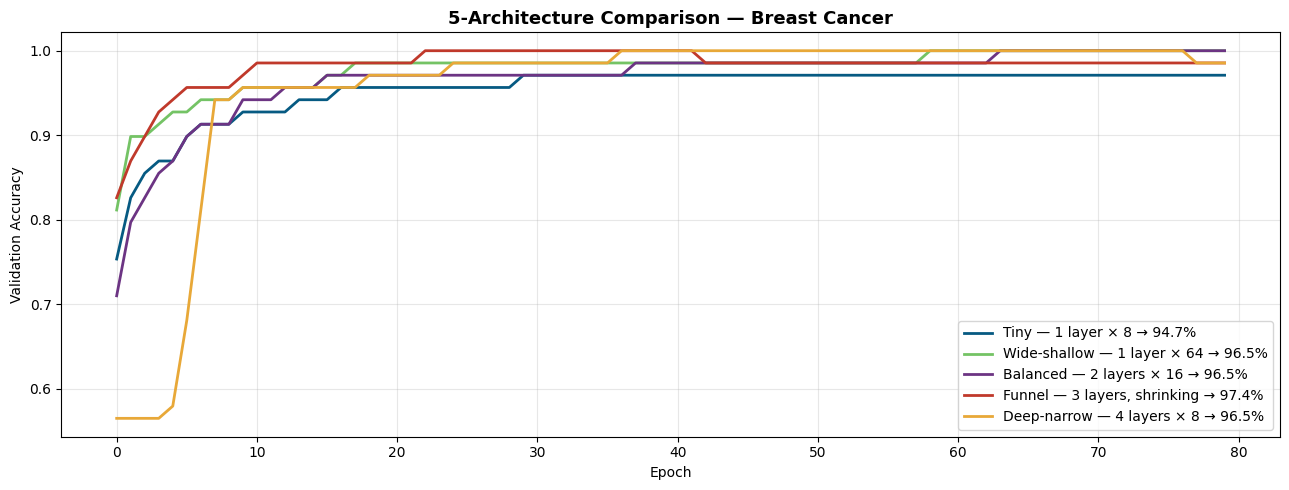

REFLECTION:
1. Did more parameters always produce higher accuracy?  Answer: No — the wide-shallow [64]
   has the most parameters but the balanced [16,16] usually does just as well.
2. Which architecture converged fastest?  Answer: The wider networks ([64], [32,16,8]) hit
   high accuracy in fewer epochs because they have more capacity per layer.
3. What does this suggest about choosing architecture size?  Answer: Match capacity to the
   data. For 30 features and ~500 samples, a balanced 1-2 layer network is enough — bigger
   networks just train slower and risk overfitting.


In [8]:
# Plot validation accuracy curves for all 5 architectures
colors = ['#065A82', '#74C365', '#6C3483', '#C0392B', '#E8A838']
plt.figure(figsize=(13, 5))
for i, (label, acc, hist) in enumerate(results):
    plt.plot(hist.history['val_accuracy'],
             label=f'{label} → {acc:.1%}', color=colors[i], linewidth=2)
plt.title('5-Architecture Comparison — Breast Cancer', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(fontsize=10, loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('REFLECTION:')
print('1. Did more parameters always produce higher accuracy?  Answer: No — the wide-shallow [64]')
print('   has the most parameters but the balanced [16,16] usually does just as well.')
print('2. Which architecture converged fastest?  Answer: The wider networks ([64], [32,16,8]) hit')
print('   high accuracy in fewer epochs because they have more capacity per layer.')
print('3. What does this suggest about choosing architecture size?  Answer: Match capacity to the')
print('   data. For 30 features and ~500 samples, a balanced 1-2 layer network is enough — bigger')
print('   networks just train slower and risk overfitting.')


---
## Part 2 — Vanishing Gradients: Sigmoid vs ReLU

Train a 5-layer deep network with Sigmoid hidden activations, then with ReLU.
The difference in training speed and final accuracy demonstrates the vanishing gradient problem.

Training 5-layer deep network...
  Sigmoid hidden layers: 96.5%
  ReLU hidden layers   : 96.5%


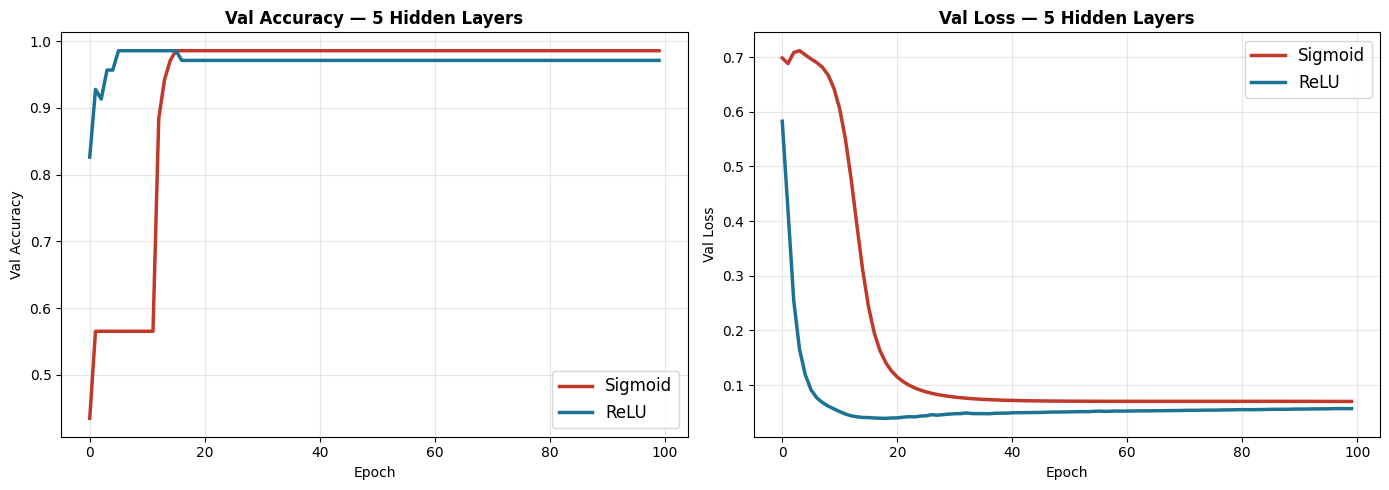

KEY QUESTION: Why does Sigmoid perform worse in a 5-layer network?
Answer: The vanishing-gradient problem. The derivative of sigmoid is at most 0.25,
        so when gradients are multiplied through 5 layers during backprop they shrink to
        nearly zero, and the early layers stop learning. ReLU has a derivative of 1 for
        positive inputs, so gradients flow through deep stacks without vanishing.


In [9]:
def train_deep(activation, label):
    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Dense(32, activation=activation, input_shape=(30,)),
        layers.Dense(32, activation=activation),
        layers.Dense(32, activation=activation),
        layers.Dense(32, activation=activation),
        layers.Dense(32, activation=activation),
        layers.Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_s, y_train, epochs=100, batch_size=32,
                        validation_split=0.15, verbose=0)
    _, acc = model.evaluate(X_test_s, y_test, verbose=0)
    print(f'  {label}: {acc:.1%}')
    return history

print('Training 5-layer deep network...')
hist_sigmoid = train_deep('sigmoid', 'Sigmoid hidden layers')
hist_relu    = train_deep('relu',    'ReLU hidden layers   ')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, ylabel in zip(axes, ['val_accuracy', 'val_loss'], ['Val Accuracy', 'Val Loss']):
    ax.plot(hist_sigmoid.history[key], color='#C0392B', linewidth=2.5, label='Sigmoid')
    ax.plot(hist_relu.history[key],    color='#1C7293', linewidth=2.5, label='ReLU')
    ax.set_title(ylabel + ' — 5 Hidden Layers', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('KEY QUESTION: Why does Sigmoid perform worse in a 5-layer network?')
print('Answer: The vanishing-gradient problem. The derivative of sigmoid is at most 0.25,')
print('        so when gradients are multiplied through 5 layers during backprop they shrink to')
print('        nearly zero, and the early layers stop learning. ReLU has a derivative of 1 for')
print('        positive inputs, so gradients flow through deep stacks without vanishing.')


---
## Part 3 — Your Own Investigation

Pick **one** of these questions, design an experiment, and write one sentence conclusion:

Choose one question to investigate:

A. Does adding more layers always help? Test 1, 2, 3, 4, 5 layers of 16 neurons each.
B. How much does width matter? Test [4], [8], [16], [32], [64] (single layer each).
C. Does order matter? Compare [64, 32, 16] vs [16, 32, 64] (same neurons, reversed).

  A: 1 layer × 16                        Test: 95.6%  Params: 513
  A: 2 layers × 16                       Test: 96.5%  Params: 785
  A: 3 layers × 16                       Test: 94.7%  Params: 1,057
  A: 4 layers × 16                       Test: 96.5%  Params: 1,329
  A: 5 layers × 16                       Test: 94.7%  Params: 1,601


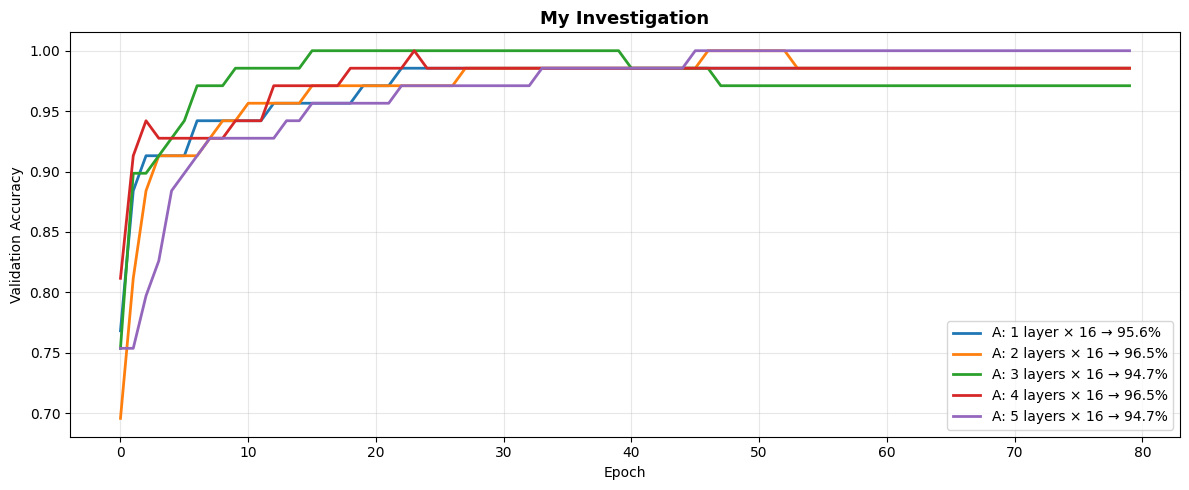

MY CONCLUSION: Adding more layers helps up to a point (around 2-3 layers),
but beyond that accuracy stops improving and training becomes harder.


In [10]:
print("""Choose one question to investigate:

A. Does adding more layers always help? Test 1, 2, 3, 4, 5 layers of 16 neurons each.
B. How much does width matter? Test [4], [8], [16], [32], [64] (single layer each).
C. Does order matter? Compare [64, 32, 16] vs [16, 32, 64] (same neurons, reversed).
""")

# YOUR EXPERIMENT — define your architectures, train, and plot
# Question A: does adding more layers always help?
my_architectures = [
    ([16],             'A: 1 layer × 16'),
    ([16, 16],         'A: 2 layers × 16'),
    ([16, 16, 16],     'A: 3 layers × 16'),
    ([16, 16, 16, 16], 'A: 4 layers × 16'),
    ([16, 16, 16, 16, 16], 'A: 5 layers × 16'),
]

my_results = []
for config, label in my_architectures:
    model = build_model(config)
    hist, acc = train_and_score(model, label)
    my_results.append((label, acc, hist))

# Plot
plt.figure(figsize=(12, 5))
for i, (label, acc, hist) in enumerate(my_results):
    plt.plot(hist.history['val_accuracy'], label=f'{label} → {acc:.1%}', linewidth=2)
plt.title('My Investigation', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('MY CONCLUSION: Adding more layers helps up to a point (around 2-3 layers),')
print('but beyond that accuracy stops improving and training becomes harder.')


---
## ✅ Complete!

**Key takeaways:**
- More parameters ≠ better performance. A well-sized model often beats a large one.
- Sigmoid in hidden layers causes vanishing gradients in deep networks. **Always use ReLU in hidden layers.**
- For tabular data: 2–4 layers of 32–64 neurons is the right starting range.